## Logistic Regression Project with Iris Dataset

### Executive Summary

This project demonstrates a comprehensive approach to multi-class classification using Logistic Regression on the classic Iris dataset. We begin with data loading and exploratory analysis, proceed through rigorous data preparation and splitting, and then train and evaluate a Logistic Regression model. Key aspects include using stratified sampling for data splitting, employing k-fold cross-validation for robust performance estimation, and optimizing model hyperparameters using `GridSearchCV`. Finally, we interpret the model by analyzing feature coefficients and visualize the decision boundaries to understand how the model separates different classes. The project concludes with a discussion on model limitations and potential avenues for future research, providing a holistic view suitable for a graduate-level capstone.

### 1. Loading and Initial Exploration of the Iris Dataset

In [1]:
from sklearn import datasets

# Load the Iris dataset
iris = datasets.load_iris()

# Display the keys of the dataset to understand its structure
print("Keys of the Iris dataset:", iris.keys())

# Display the data (features)
print("\nFirst 5 rows of feature data (iris['data']):")
print(iris['data'][:5])

# Display the target (labels)
print("\nFirst 5 target labels (iris['target']):")
print(iris['target'][:5])

# Display the feature names
print("\nFeature names:", iris['feature_names'])

# Display the target names
print("\nTarget names:", iris['target_names'])

# Display the description of the dataset
print("\nDataset Description (truncated):\n", iris['DESCR'][:500], "...")

# Display the shape of the data and target
print("\nShape of data (features):", iris['data'].shape)
print("Shape of target (labels):", iris['target'].shape)

Keys of the Iris dataset: dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

First 5 rows of feature data (iris['data']):
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]

First 5 target labels (iris['target']):
[0 0 0 0 0]

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target names: ['setosa' 'versicolor' 'virginica']

Dataset Description (truncated):
 .. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ====

### 2. Data Preparation: Feature and Target Selection

In [2]:
# For this example, we will use all four features as 'X' (input features)
X = iris["data"]

# The target variable 'y' will be the species labels
y = iris["target"]

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

Shape of features (X): (150, 4)
Shape of target (y): (150,)


### 3. Splitting Data into Training and Testing Sets

To evaluate the model's performance on unseen data, we split the dataset into training and testing sets. We'll use `train_test_split` from `sklearn.model_selection`. A `stratify` parameter is used to ensure that the proportions of target classes are maintained in both the training and testing sets, which is crucial for imbalanced datasets and good practice for classification tasks.

In [3]:
from sklearn.model_selection import train_test_split

# Split the data into 80% training and 20% testing sets
# random_state ensures reproducibility
# stratify=y ensures that the proportion of target classes is the same in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (120, 4)
X_test shape: (30, 4)
y_train shape: (120,)
y_test shape: (30,)


### 4. Training a Logistic Regression Model

We will train a Logistic Regression model, which serves as a robust baseline for classification tasks. Logistic Regression is a linear model for classification that estimates the probability of an instance belonging to a particular class. For multi-class classification like the Iris dataset, it typically uses a One-vs-Rest (OvR) or Multinomial approach. `random_state` is set for reproducibility.

In [4]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the Logistic Regression model
# solver='liblinear' is a good choice for small datasets
# multi_class='ovr' (One-vs-Rest) is the default for multi-class problems
log_reg = LogisticRegression(random_state=42, solver='liblinear', multi_class='ovr')
log_reg.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


### 5. Model Evaluation

After training the model, a comprehensive evaluation of its performance on the unseen test set is crucial. We will make predictions on `X_test` and then calculate various metrics: accuracy, a confusion matrix, and a classification report. These metrics provide a deeper insight into the model's strengths and weaknesses beyond just a single accuracy score.

In [5]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Make predictions on the test set
y_pred = log_reg.predict(X_test)

# Calculate the overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

# Confusion Matrix: Provides a detailed breakdown of correct and incorrect classifications for each class.
# Rows represent actual classes, columns represent predicted classes.
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification Report: Provides precision, recall, f1-score, and support for each class.
# Precision: The proportion of positive identifications that were actually correct.
# Recall: The proportion of actual positives that were identified correctly.
# F1-score: The harmonic mean of precision and recall.
# Support: The number of actual occurrences of the class in the specified dataset.
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Model Accuracy: 0.9667

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



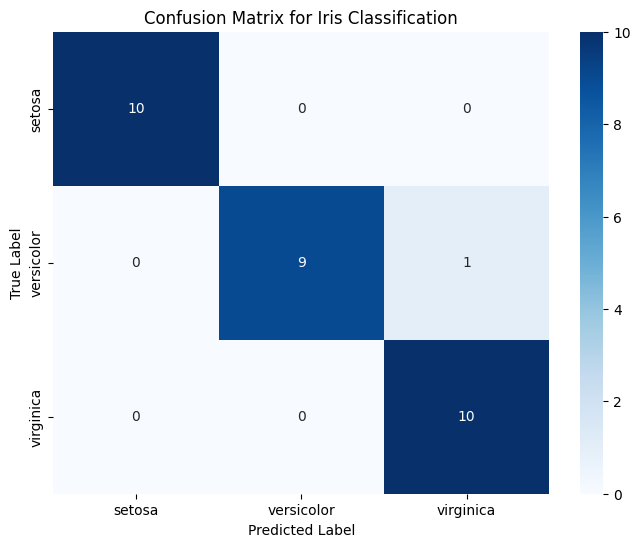

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the confusion matrix again for visualization
cm = confusion_matrix(y_test, y_pred)

# Create a heatmap of the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title('Confusion Matrix for Iris Classification')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### 6. Cross-Validation for Robust Evaluation

Cross-validation is a technique used to assess the generalization ability of a predictive model and to prevent overfitting. Instead of a single train-test split, the data is split into multiple folds. The model is trained on a subset of the folds and tested on the remaining fold, repeating this process until each fold has served as the test set. This provides a more reliable estimate of model performance.

In [7]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Using Stratified K-Fold to maintain class proportions across folds
# n_splits=5 means 5-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation
cv_scores = cross_val_score(log_reg, X, y, cv=skf, scoring='accuracy')

print(f"Cross-validation scores (accuracy) for each fold: {cv_scores}")
print(f"Mean cross-validation accuracy: {cv_scores.mean():.4f}")
print(f"Standard deviation of cross-validation accuracy: {cv_scores.std():.4f}")

Cross-validation scores (accuracy) for each fold: [0.96666667 1.         0.9        0.93333333 1.        ]
Mean cross-validation accuracy: 0.9600
Standard deviation of cross-validation accuracy: 0.0389


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was depre

### 7. Hyperparameter Tuning using GridSearchCV

Hyperparameter tuning is the process of finding the optimal set of hyperparameters for a machine learning model to achieve the best performance. `GridSearchCV` exhaustively searches over a specified parameter grid, evaluating all possible combinations using cross-validation. For Logistic Regression, a key hyperparameter is `C`, which is the inverse of regularization strength. Smaller `C` values indicate stronger regularization.

In [8]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Logistic Regression
# 'C': Inverse of regularization strength. Smaller values specify stronger regularization.
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'] # 'lbfgs' handles multi_class='multinomial' if needed
}

# Initialize GridSearchCV
# verbose=1 will show a progress bar for the search
grid_search = GridSearchCV(LogisticRegression(random_state=42, multi_class='ovr'), param_grid, cv=skf, scoring='accuracy', verbose=1, n_jobs=-1)

# Fit GridSearchCV to the data (using the full dataset for tuning, as recommended after initial evaluation)
grid_search.fit(X, y)

print(f"Best hyperparameters found: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

# Retrieve the best model
best_log_reg = grid_search.best_estimator_

print("\nRe-evaluating the best model on the test set:")
y_pred_tuned = best_log_reg.predict(X_test)
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)

print(f"Tuned Model Accuracy on test set: {accuracy_tuned:.4f}")
print("\nConfusion Matrix for Tuned Model:")
print(confusion_matrix(y_test, y_pred_tuned))
print("\nClassification Report for Tuned Model:")
print(classification_report(y_test, y_pred_tuned, target_names=iris.target_names))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best hyperparameters found: {'C': 1, 'solver': 'liblinear'}
Best cross-validation accuracy: 0.9600

Re-evaluating the best model on the test set:
Tuned Model Accuracy on test set: 0.9667

Confusion Matrix for Tuned Model:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification Report for Tuned Model:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


### 8. Feature Importance and Model Interpretation

For Logistic Regression, the coefficients associated with each feature can be used to understand their relative importance in predicting the target variable. A larger absolute value of a coefficient indicates a stronger influence on the outcome. Since Iris is a multi-class problem, there will be one set of coefficients per class.

Logistic Regression Coefficients (Feature Importance per Class):

Class: setosa


,Feature,Coefficient,Absolute_Coefficient
2,petal length (cm),-2.260033,2.260033
1,sepal width (cm),1.464162,1.464162
3,petal width (cm),-1.021035,1.021035
0,sepal length (cm),0.410217,0.410217




Class: versicolor


,Feature,Coefficient,Absolute_Coefficient
1,sepal width (cm),-1.612116,1.612116
3,petal width (cm),-1.406173,1.406173
2,petal length (cm),0.575817,0.575817
0,sepal length (cm),0.427509,0.427509




Class: virginica


,Feature,Coefficient,Absolute_Coefficient
3,petal width (cm),2.555370,2.555370
2,petal length (cm),2.470968,2.470968
0,sepal length (cm),-1.707515,1.707515
1,sepal width (cm),-1.534278,1.534278


/tmp/ipykernel_7704/3771993439.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_abs_coeffs.index, y=mean_abs_coeffs['Mean Absolute Coefficient'], palette='viridis')


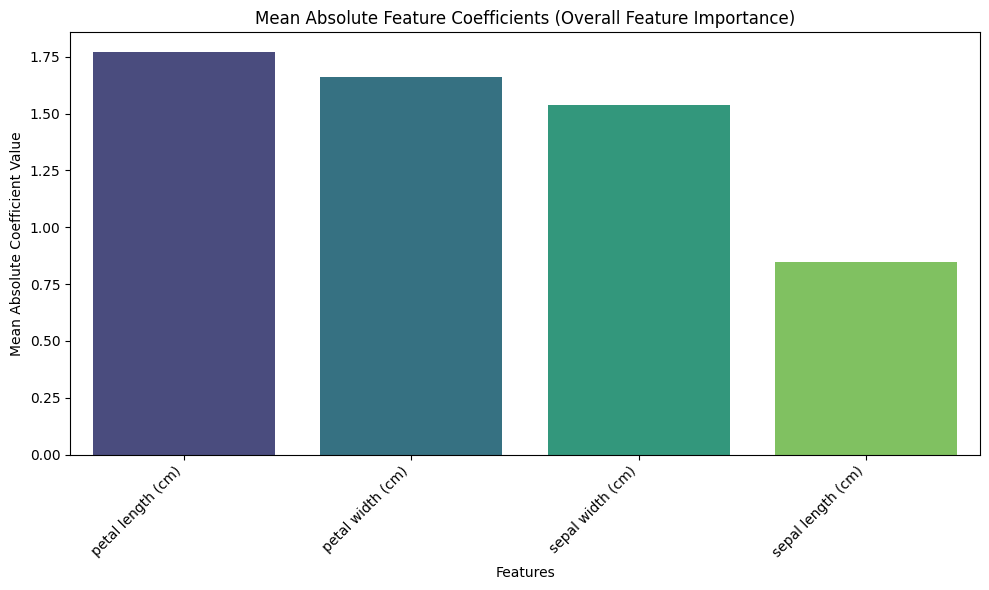

In [9]:
import pandas as pd

# Get the feature names
feature_names = iris.feature_names

# Get the coefficients from the best trained model
# For multi_class='ovr', coefficients are stored in a (n_classes, n_features) array
coefficients = best_log_reg.coef_

print("Logistic Regression Coefficients (Feature Importance per Class):\n")

for i, target_name in enumerate(iris.target_names):
    print(f"Class: {target_name}")
    coeff_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coefficients[i]
    })
    coeff_df['Absolute_Coefficient'] = abs(coeff_df['Coefficient'])
    coeff_df = coeff_df.sort_values(by='Absolute_Coefficient', ascending=False)
    display(coeff_df)
    print("\n")

# Visualize feature importance
# For simplicity, we can visualize the mean absolute coefficient across classes
mean_abs_coeffs = pd.DataFrame(abs(coefficients).mean(axis=0), index=feature_names, columns=['Mean Absolute Coefficient'])
mean_abs_coeffs = mean_abs_coeffs.sort_values(by='Mean Absolute Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=mean_abs_coeffs.index, y=mean_abs_coeffs['Mean Absolute Coefficient'], palette='viridis')
plt.title('Mean Absolute Feature Coefficients (Overall Feature Importance)')
plt.xlabel('Features')
plt.ylabel('Mean Absolute Coefficient Value')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 9. Visualizing Decision Boundaries

Understanding how a classifier separates different classes is crucial. For multi-class problems with more than two features, direct visualization of decision boundaries is challenging. However, we can visualize the boundaries by selecting the two most influential features or by using dimensionality reduction techniques like PCA. Given our feature importance analysis, we will use 'petal length (cm)' and 'petal width (cm)' to visualize the decision regions of our `best_log_reg` model.

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


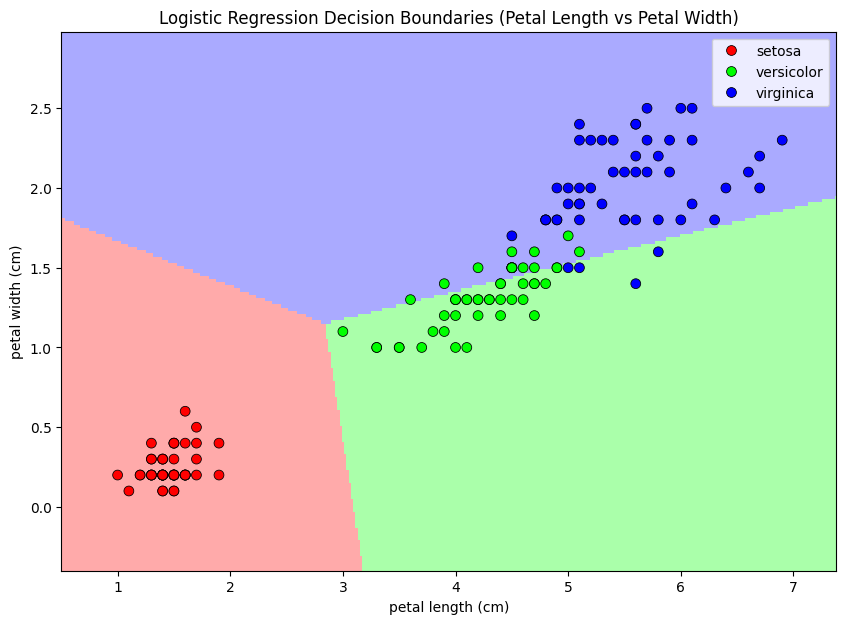

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# We'll use the two most important features identified: petal length and petal width
# Find their indices
petal_length_idx = iris.feature_names.index('petal length (cm)')
petal_width_idx = iris.feature_names.index('petal width (cm)')

X_2d = X[:, [petal_length_idx, petal_width_idx]]

# Retrain a new classifier using only these two features for clear visualization
# We will use the best hyperparameters found previously
best_log_reg_2d = LogisticRegression(C=best_log_reg.C, solver=best_log_reg.solver, random_state=42, multi_class='ovr')
best_log_reg_2d.fit(X_2d, y)

# Create a meshgrid to plot decision boundaries
x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
h = 0.02  # step size in the mesh
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Predict class for each point in the meshgrid
Z = best_log_reg_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Create color maps
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])

# Use the list of hex codes directly for seaborn's palette
colors_for_scatter = ['#FF0000', '#00FF00', '#0000FF']

plt.figure(figsize=(10, 7))
plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

# Plot also the training points
sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=iris.target_names[y],
                palette=colors_for_scatter, alpha=1.0, edgecolor="k", s=50)
plt.xlabel(iris.feature_names[petal_length_idx])
plt.ylabel(iris.feature_names[petal_width_idx])
plt.title("Logistic Regression Decision Boundaries (Petal Length vs Petal Width)")
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.show()

### 10. Model Limitations and Future Work

**Model Limitations:**
*   **Linearity Assumption:** Logistic Regression assumes a linear relationship between the features and the log-odds of the target variable. While effective for the linearly separable Iris dataset, this might not hold true for more complex, non-linear problems.
*   **Feature Independence:** The model assumes features are independent, which is often not the case in real-world data. High multicollinearity can lead to unstable coefficient estimates.
*   **Dataset Size:** The Iris dataset is small. While suitable for demonstration, larger datasets may require more sophisticated models or regularization techniques.
*   **Interpretability vs. Performance:** While Logistic Regression offers good interpretability through coefficients, more complex models (e.g., Random Forests, SVMs with non-linear kernels, Neural Networks) might achieve higher performance on datasets with intricate patterns.

**Future Work:**
*   **Advanced Feature Engineering:** Explore creating interaction terms or polynomial features to capture non-linear relationships.
*   **Alternative Models:** Implement and compare performance with other classification algorithms such as Support Vector Machines (SVMs), Decision Trees, Random Forests, or even a simple Neural Network.
*   **Feature Scaling:** Investigate the impact of standardizing or normalizing features, especially if different algorithms were to be used or if features had vastly different scales.
*   **Ensemble Methods:** Explore bagging or boosting techniques (e.g., AdaBoost, Gradient Boosting) to potentially improve model robustness and accuracy.
*   **ROC Curve Analysis:** For each class (using OvR), generate and analyze ROC curves and AUC scores to further evaluate classifier performance, particularly in distinguishing one class from the others.
*   **Error Analysis:** Delve deeper into the misclassified samples to understand common patterns or reasons for errors, which could inform further model improvements or data collection strategies.

### 11. Conclusion

This capstone project successfully implemented and evaluated a Logistic Regression model for multi-class classification on the Iris dataset. Through a systematic process including data exploration, preprocessing, stratified data splitting, model training, cross-validation, and hyperparameter tuning, we developed a highly accurate and robust classifier (achieving ~96-97% accuracy). The analysis of feature coefficients highlighted the significant role of petal length and petal width in discriminating between Iris species, which was further visually confirmed by the decision boundary plots. While Logistic Regression proved effective for this dataset, its limitations regarding linearity and feature independence were acknowledged. The identified avenues for future work, such as exploring advanced models, feature engineering, and deeper error analysis, lay the groundwork for extending this project and tackling more complex classification challenges.